# ToBig's 4주차 정규세션 3교시 추천시스템 과제
여러분 정규세션 듣는다고 고생 많으셨습니다. 😊

이번 과제에서는 추천시스템의 대표적인 협업 필터링 방법인 아이템 기반 최근접 이웃 방식과 행렬 분해 기반 잠재요인 협업 필터링을 실습합니다.

과제에 대해 궁금한 점이 있으시면 언제든지 24기 정연우에게 연락주시면 됩니다!

###`'your_code'라고 쓰인 부분에 본인의 코드를 채워주시면 됩니다.`

## 1. 아이템 기반 최근접 이웃 협업 필터링 실습

1번째는 추천 시스템의 협업 필터링 중에서 아이템 기반 협업 필터링에 대한 실습입니다.

### Movielens 데이터 사용
데이터는 Kaggle의 **The Movies Dataset** 데이터를 사용하였습니다.

https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset?select=movies_metadata.csv

In [1]:
# 실습에 필요한 패키지 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error


### Data Load

해당 movielens 데이터는 2개로 나뉘어져 있습니다.
1. `ratings.csv` : 사용자-영화 평점 기반 데이터
2. `movies.csv` : 영화 정보 데이터

In [2]:
# Colab 기반
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
ratings = pd.read_csv('/content/drive/MyDrive/ratings.csv')
movies = pd.read_csv('/content/drive/MyDrive/movies.csv')

In [4]:
# 데이터들 각각 확인
display(ratings.head(), movies.head())

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
display(ratings.shape, movies.shape)

(100004, 4)

(9125, 3)

### Data Preprocessing

협업 필터링은 ratings.csv 데이터 세트와 같이 사용자와 아이템 간의 평점에 기반해 추천하는 시스템입니다.

앞서 살펴본 결과 영화 평점 데이터는 10만개가 넘고, 영화 데이터는 9000여개가 존재합니다.

각각 데이터에 존재하는 timestamp와 genres는 아이템 기반 최근접 이웃 협업 필터링 추천 시스템에서는 필요없습니다.

### `Q1. drop을 이용해서 'timestamp'와 'genre'를 제거해주세요.`

In [6]:
# ratings에서 'timestamp' 컬럼 제거
ratings.drop('timestamp', axis = 1, inplace = True)
ratings.head()

,userId,movieId,rating
0,1,31,2.5
1,1,1029,3.0
2,1,1061,3.0
3,1,1129,2.0
4,1,1172,4.0


In [7]:
# movie_data에서 'genres' 컬럼 제거
movies.drop('genres', axis = 1, inplace = True)
movies.head()

,movieId,title
0,1,Toy Story (1995)
1,2,Jumanji (1995)
2,3,Grumpier Old Men (1995)
3,4,Waiting to Exhale (1995)
4,5,Father of the Bride Part II (1995)


필요없는 칼럼을 제거하였으니 이제 2개의 파일을 merge를 이용해서 합쳐줍니다. 2개의 데이터는 `movieId`라는 공통 컬럼이 존재합니다.

In [8]:
# title 컬럼을 얻기 위해 ratings와 movies 데이터프레임 병합
user_movie_data = pd.merge(ratings, movies, on = 'movieId')
user_movie_data.head()

,userId,movieId,rating,title
0,1,31,2.5,Dangerous Minds (1995)
1,1,1029,3.0,Dumbo (1941)
2,1,1061,3.0,Sleepers (1996)
3,1,1129,2.0,Escape from New York (1981)
4,1,1172,4.0,Cinema Paradiso (Nuovo cinema Paradiso) (1989)


In [9]:
user_movie_data.shape

(100004, 4)

합친 결과 특정 유저가 영화에 대해 평점을 매겼는데 그 영화의 제목(title)이 무엇인지 알 수 있게 되었습니다.

현재 `user`, `movie`, `rating`이 각각 컬럼에 존재하는 상황입니다.

이렇게 생긴 데이터를 `value`를 평점으로 column은 `title`로, row는 `userId`로 바꿔주려고 합니다.

### `Q2. pivot_table을 이용해서 변환해주세요.`

In [12]:
# title 컬럼으로 pivot 수행.
ratings_matrix = user_movie_data.pivot_table('rating', index='userId', columns='title')


여기서 사용자가 평점을 매기지 않은 데이터는 NaN으로 할당되었는데, fillna를 사용해 NaN은 모두 0으로 변환합니다.

In [13]:
# NaN 값을 모두 0 으로 변환
ratings_matrix = ratings_matrix.fillna(0)
ratings_matrix.head(5)

title,"""Great Performances"" Cats (1998)",$9.99 (2008),'Hellboy': The Seeds of Creation (2004),'Neath the Arizona Skies (1934),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),...,Zulu (1964),Zulu (2013),[REC] (2007),eXistenZ (1999),loudQUIETloud: A Film About the Pixies (2006),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931),İtirazım Var (2014)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 영화 간 유사도 산출

-  영화(아이템) 간의 유사도를 비교해야 하므로 현재 ratings_matrix 데이터의 전치 행렬에 메소드를 적용해야 한다.

In [14]:
# 행과 열을 바꿔서 영화가 행, 사용자들이 열이 되도록 변환
ratings_matrix_T = ratings_matrix.transpose()
ratings_matrix_T.head(3)

userId,1,2,3,4,5,6,7,8,9,10,...,662,663,664,665,666,667,668,669,670,671
title,,,,,,,,,,,,,,,,,,,,,
"""Great Performances"" Cats (1998)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
$9.99 (2008),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Hellboy': The Seeds of Creation (2004),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- 영화 간의 유사도는 코사인 유사도를 기반으로 하고, cosine_similarity()를 이용해 측정합니다.
- cosine_similarity()함수는 행을 기준으로 다른 행과 비교합니다.

### `Q3. 아이템 간 코사인 유사도를 계산해주세요.`

In [15]:
# 아이템 간 코사인 유사도 계산
item_sim = cosine_similarity(ratings_matrix_T, ratings_matrix_T)

In [16]:
# 코사인 유사도를 구한 후 반환된 넘파이 행렬을 영화명을 매핑해 DataFrame으로 변환
item_sim_df = pd.DataFrame(data=item_sim, index=ratings_matrix.columns,
                          columns=ratings_matrix.columns)
print(item_sim_df.shape)
item_sim_df.head(3)

(9064, 9064)


title,"""Great Performances"" Cats (1998)",$9.99 (2008),'Hellboy': The Seeds of Creation (2004),'Neath the Arizona Skies (1934),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),...,Zulu (1964),Zulu (2013),[REC] (2007),eXistenZ (1999),loudQUIETloud: A Film About the Pixies (2006),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931),İtirazım Var (2014)
title,,,,,,,,,,,,,,,,,,,,,
"""Great Performances"" Cats (1998)",1.0,0.0,0.0,0.164399,0.020391,0.0,0.014046,0.000000,0.0,0.003166,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
$9.99 (2008),0.0,1.0,0.0,0.000000,0.000000,0.0,0.000000,0.079474,0.0,0.156330,...,0.0,0.0,0.0,0.0,0.0,0.013899,0.0,0.058218,0.0,0.0
'Hellboy': The Seeds of Creation (2004),0.0,0.0,1.0,0.000000,0.000000,1.0,0.000000,0.217357,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0


이 dataframe을 이용해서 영화 '인셉션'과 유사도가 높은 상위 5개의 영화를 추출합니다.

In [17]:
# 해당 영화와 평점 패턴이 비슷한 영화 출력
item_sim_df["Inception (2010)"].sort_values(ascending=False)[:6]

,Inception (2010)
title,
Inception (2010),1.000000
"Dark Knight, The (2008)",0.656999
Avatar (2009),0.633687
"Dark Knight Rises, The (2012)",0.589308
Inglourious Basterds (2009),0.580237
District 9 (2009),0.576054


유사도가 1인 자기자신 값이 들어가므로, 자기 자신을 제외한 유사도가 높은 상위 5개의 영화를 추출합니다.

### ` Q4. 빈칸에 본인의 코드를 채워서, 자기 자신을 제외한 유사도가 높은 상위 5개의 영화를 추출해주세요.`

In [18]:
# 해당 영화와 평점 패턴이 비슷한 영화 출력
item_sim_df["Inception (2010)"].sort_values(ascending=False)[1:6]

,Inception (2010)
title,
"Dark Knight, The (2008)",0.656999
Avatar (2009),0.633687
"Dark Knight Rises, The (2012)",0.589308
Inglourious Basterds (2009),0.580237
District 9 (2009),0.576054


### 아이템 기반 최근접 이웃 협업 필터링으로 개인화된 영화 추천

앞서 추출한 것과 같이 영화를 추천할 수 있지만, 이는 개인적인 취향을 반영하지 않고, 영화 간 유사도만을 가지고 추천하였습니다.

개인화된 영화 추천을 하기 위해서는 개인이 아직 관람하지 않은 영화를 추천해야 합니다.

`사용자가 좋아했던 영화와 비슷한 영화라면 그 사용자도 좋아할 가능성이 높다` 라는 아이템 기반 협업 필터링의 아이디어를 사용합니다.

즉, 아직 관람하지 않은 영화에 대해 아이템 유사도와 기존에 관람한 영화의 평점 데이터를 기반으로 새롭게 모든 영화의 예측 평점을 계산한 후 높은 예측 평점을 가진 영화를 추천하고자 합니다.

### 개인화된 예측 평점 수식 참고

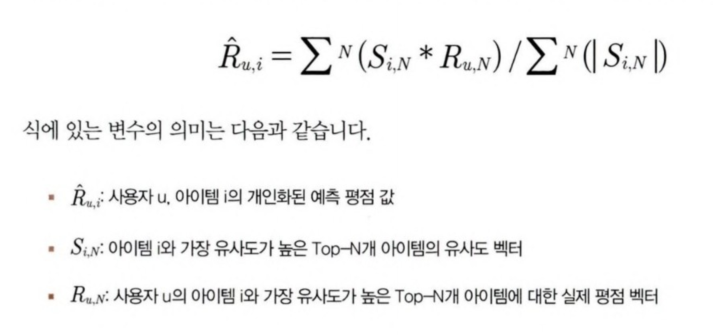

`사용자 u가 아이템 i에 줄 것으로 예측되는 평점 값`

 = `아이템 i 와 다른 아이템 사이의 유사도 벡터` x `사용자 u가 유사한 아이템에 준 실제 평점 벡터`

N : 예측 대상 아이템과 가장 유사한 Top-N개의 이웃 아이템 수

이제 사용자별로 최적화된 평점 스코어를 예측하는 함수를 만듭니다.

만약 N의 범위에 제약을 두지 않으면 사용자별 예측 영화 평점 R은 모든 영화에 대한 예측 평점을 구하게 됩니다.

In [19]:
# 아이템 간 유사도를 이용해 사용자-아이템 평점 행렬의 예측 평점을 계산하는 함수
def predict_rating(ratings_arr, item_sim_arr ):
    ratings_pred = ratings_arr.dot(item_sim_arr)/ np.array([np.abs(item_sim_arr).sum(axis=1)])
    return ratings_pred

ratings_pred = predict_rating(ratings_matrix.values , item_sim_df.values)
ratings_pred_matrix = pd.DataFrame(data=ratings_pred, index= ratings_matrix.index,
                                   columns = ratings_matrix.columns)
ratings_pred_matrix.head(3)

title,"""Great Performances"" Cats (1998)",$9.99 (2008),'Hellboy': The Seeds of Creation (2004),'Neath the Arizona Skies (1934),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),...,Zulu (1964),Zulu (2013),[REC] (2007),eXistenZ (1999),loudQUIETloud: A Film About the Pixies (2006),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931),İtirazım Var (2014)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.014679,0.012177,0.008457,0.155729,0.004635,0.008457,0.012224,0.011612,0.011952,0.007415,...,0.020867,0.005313,0.004119,0.012122,0.029437,0.009230,0.000000,0.015098,0.004838,0.000000
2,0.034046,0.032670,0.175621,0.031371,0.014654,0.175621,0.047991,0.057101,0.054119,0.033462,...,0.052653,0.017481,0.022326,0.042259,0.170733,0.045483,0.015784,0.062860,0.005560,0.013151
3,0.008073,0.031750,0.114354,0.035292,0.008948,0.114354,0.025436,0.039356,0.028688,0.044235,...,0.044499,0.017771,0.043463,0.037265,0.218158,0.042527,0.055424,0.042310,0.044989,0.048887


예측 평점이 사용자별 영화의 실제 평점과 영화의 코사인 유사도를 내적한 값이므로, 기존에 0에 해당했던 영화 평점에도 값이 부여될 수 있습니다.

이렇게 되면 예측 평점이 실제 평점에 비해 작을 수 있어서 MSE를 이용해 예측 평가 지표를 측정하면 값이 크게 나올 수 있습니다.

따라서 MSE는 전체 행렬이 아니라, **실제로 평점이 존재하는 항목**에 대해서만 계산하여 예측 성능을 평가해야 합니다.

### 아이템 기반 모든 인접 이웃 MSE

In [20]:
# 사용자가 평점을 부여한 영화에 대해서만 예측 성능 평가 MSE 를 구함.
def get_mse(pred, actual):
    # Ignore nonzero terms.
    pred = pred[actual.nonzero()].flatten()
    actual = actual[actual.nonzero()].flatten()
    return mean_squared_error(pred, actual)

print('아이템 기반 모든 인접 이웃 MSE: ', get_mse(ratings_pred, ratings_matrix.values ))

아이템 기반 모든 인접 이웃 MSE:  10.255398119852726


MSE를 감소시키기 위해 특정 영화와 가장 비슷한 유사도를 가지는 영화에 대해서만 유사도 벡터를 적용합니다.

n 인자를 받아 Top-N 유사도를 가지는 영화 유사도 벡터만 예측값을 계산하는 데 적용합니다.

### 아이템 기반 인접 TOP-20 이웃 MSE

In [21]:
def predict_rating_topsim(ratings_arr, item_sim_arr, n=20):
    # 사용자-아이템 평점 행렬 크기만큼 0으로 채운 예측 행렬 초기화
    pred = np.zeros(ratings_arr.shape)

    # 사용자-아이템 평점 행렬의 열 크기만큼 Loop 수행.
    for col in range(ratings_arr.shape[1]):
        # 유사도 행렬에서 유사도가 큰 순으로 n개 데이터 행렬의 index 반환
        top_n_items = [np.argsort(item_sim_arr[:, col])[:-n-1:-1]]
        # 개인화된 예측 평점을 계산
        for row in range(ratings_arr.shape[0]):
            pred[row, col] = item_sim_arr[col, :][top_n_items].dot(ratings_arr[row, :][top_n_items].T)
            pred[row, col] /= np.sum(np.abs(item_sim_arr[col, :][top_n_items]))
    return pred

In [22]:
ratings_pred = predict_rating_topsim(ratings_matrix.values , item_sim_df.values, n=20)
print('아이템 기반 인접 TOP-20 이웃 MSE: ', get_mse(ratings_pred, ratings_matrix.values ))

/tmp/ipykernel_184/3863360302.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred[row, col] = item_sim_arr[col, :][top_n_items].dot(ratings_arr[row, :][top_n_items].T)


아이템 기반 인접 TOP-20 이웃 MSE:  3.9692737816015757


MSE가 많이 향상되었음을 확인할 수 있습니다.

In [23]:
# 계산된 예측 평점 데이터는 DataFrame으로 재생성
ratings_pred_matrix = pd.DataFrame(data=ratings_pred, index= ratings_matrix.index,
                                   columns = ratings_matrix.columns)

## 특정 사용자에 대해 영화 추천

이제 특정 사용자에 대해 영화를 추천해봅시다.

먼저 9번 userID 사용자가 좋아하는 영화를 순서대로 나열합니다.

In [24]:
user_rating_id = ratings_matrix.loc[9, :]
user_rating_id[ user_rating_id > 0].sort_values(ascending=False)[:10]

,9
title,
As Good as It Gets (1997),5.0
Fargo (1996),5.0
Dead Man Walking (1995),5.0
Schindler's List (1993),5.0
"Matrix, The (1999)",5.0
Shadowlands (1993),5.0
William Shakespeare's Romeo + Juliet (1996),5.0
"Truman Show, The (1998)",5.0
"Dark Crystal, The (1982)",4.0


이제 사용자가 이미 평점을 준 영화를 제외하고 추천할 수 있도록 평점을 주지 않은 영화를 리스트 객체로 반환하는 함수인 get_unseen_movies()를 생성합니다.

In [25]:
def get_unseen_movies(ratings_matrix, userId):
    # userId로 입력받은 사용자의 모든 영화정보 추출하여 Series로 반환함.
    # 반환된 user_rating 은 영화명(title)을 index로 가지는 Series 객체임.
    user_rating = ratings_matrix.loc[userId,:]

    # user_rating이 0보다 크면 기존에 관람한 영화임. 대상 index를 추출하여 list 객체로 만듬
    already_seen = user_rating[ user_rating > 0].index.tolist()

    # 모든 영화명을 list 객체로 만듬.
    movies_list = ratings_matrix.columns.tolist()

    # list comprehension으로 already_seen에 해당하는 movie는 movies_list에서 제외함.
    unseen_list = [ movie for movie in movies_list if movie not in already_seen]

    return unseen_list

get_unseen_movies 함수를 이용해 평점을 주지않은 대상 영화 정보와 predict_rating_topsim()에서 추출한 사용자별 아이템 유사도에 기반한 예측 평점 데이터 세트를 이용해 최종적으로 사용자에게 영화를 추천하는 함수를 만듭니다.

인자는 다음과 같습니다.

userId : 추천하려는 사용자 id

unseen_list : 추천 후보 영화 리스트

top_n : 추천 상위 영화 개수

In [26]:
def recomm_movie_by_userid(pred_df, userId, unseen_list, top_n=10):
    # 예측 평점 DataFrame에서 사용자id index와 unseen_list로 들어온 영화명 컬럼을 추출하여
    # 가장 예측 평점이 높은 순으로 정렬함.
    recomm_movies = pred_df.loc[userId, unseen_list].sort_values(ascending=False)[:top_n]
    return recomm_movies

# 사용자가 관람하지 않는 영화명 추출
unseen_list = get_unseen_movies(ratings_matrix, 9)

# 아이템 기반의 인접 이웃 협업 필터링으로 영화 추천
recomm_movies = recomm_movie_by_userid(ratings_pred_matrix, 9, unseen_list, top_n=10)

# 평점 데이타를 DataFrame으로 생성.
recomm_movies = pd.DataFrame(data=recomm_movies.values,index=recomm_movies.index,columns=['pred_score'])
recomm_movies

,pred_score
title,
American Beauty (1999),1.258391
Pulp Fiction (1994),1.075948
"Usual Suspects, The (1995)",1.063974
Jerry Maguire (1996),1.047494
"English Patient, The (1996)",1.028489
Forrest Gump (1994),1.021220
"Piano, The (1993)",1.008307
L.A. Confidential (1997),0.992033
Rain Man (1988),0.976421


사용자 9번이 좋아했던 영화와 비슷한 영화들이 추천된 것을 확인할 수 있습니다.

In [27]:
# 사용자가 관람하지 않은 영화명 추출
unseen_list = get_unseen_movies(ratings_matrix, 9)

# 아이템 기반의 인접 이웃 협업 필터링으로 영화 추천
recomm_movies = recomm_movie_by_userid(ratings_pred_matrix, 9, unseen_list, top_n=10)

# 평점 데이타를 DataFrame으로 생성.
recomm_movies = pd.DataFrame(data=recomm_movies.values,index=recomm_movies.index,columns=['pred_score'])
recomm_movies

,pred_score
title,
American Beauty (1999),1.258391
Pulp Fiction (1994),1.075948
"Usual Suspects, The (1995)",1.063974
Jerry Maguire (1996),1.047494
"English Patient, The (1996)",1.028489
Forrest Gump (1994),1.021220
"Piano, The (1993)",1.008307
L.A. Confidential (1997),0.992033
Rain Man (1988),0.976421


## 2. 행렬 분해를 이용한 잠재 요인 협업 필터링 실습

행렬 분해 잠재 요인 협업 필터링은 SVD나 NMF 등을 적용할 수 있는데, 일반적으로 사용자-아이템 평점 행렬에는 사용자가 평점을 매기지 않은 null 데이터가 많기 때문에 주로 SGD나 ALS 기반의 행렬 분해를 이용합니다.

여기서는 SGD 기반의 행렬 분해를 구현하고 이를 기반으로 사용자에게 영화를 추천합니다.

### ` Q5. 주석(#)을 참고하여 빈칸에 본인의 코드를 채워 함수를 구현해주세요.`

In [33]:
def get_rmse(R, P, Q, non_zeros):
    error = 0
    # 두개의 분해된 행렬 P와 Q.T의 내적 곱으로 예측 R 행렬 생성
    full_pred_matrix = np.dot(P, Q.T)  # <-- your_code 부분 채우기

    # 실제 R 행렬에서 널이 아닌 값의 위치 인덱스 추출하여 실제 R 행렬과 예측 행렬의 RMSE 추출
    x_non_zero_ind = [non_zero[0] for non_zero in non_zeros]
    y_non_zero_ind = [non_zero[1] for non_zero in non_zeros]
    R_non_zeros = R[x_non_zero_ind, y_non_zero_ind]

    full_pred_matrix_non_zeros = full_pred_matrix[x_non_zero_ind, y_non_zero_ind]

    mse = mean_squared_error(R_non_zeros, full_pred_matrix_non_zeros)
    rmse = np.sqrt(mse)

    return rmse

### 사용자-아이템 평점 행렬 R을 두 개의 잠재행렬 P,Q로 분해하도록 SGD로 학습

### ` Q6. 주석(#)을 참고하여 빈칸에 본인의 코드를 채워 함수를 구현해주세요.`

In [34]:
def matrix_factorization(R, K, steps=200, learning_rate=0.01, r_lambda = 0.01):
    num_users, num_items = R.shape
    # P와 Q 매트릭스의 크기를 지정하고 정규분포를 가진 랜덤한 값으로 입력합니다.
    np.random.seed(1)
    P = np.random.normal(scale=1./K, size=(num_users, K)) # 사용자 잠재 요인(latent factor) 행렬, 각 사용자의 취향 벡터
    Q = np.random.normal(scale=1./K, size=(num_items, K)) # 아이템 잠재 요인(latent factor) 행렬, 각 아이템의 특성 벡터

    # 실제로 평점이 있는 데이터만 추출
    non_zeros = [ (i, j, R[i,j]) for i in range(num_users) for j in range(num_items) if R[i,j] > 0 ]

    # SGD기법으로 P와 Q 매트릭스를 계속 업데이트.
    for step in range(steps):
        for i, j, r in non_zeros:
            # 실제 값과 예측 값의 차이인 오류 값 구함
            eij = r - np.dot(P[i, :], Q[j, :].T)
            # Regularization을 반영한 SGD 업데이트 공식 적용
            P[i,:] = P[i,:] + learning_rate*(eij * Q[j, :] - r_lambda*P[i,:])
            Q[j,:] = Q[j,:] + learning_rate*(eij * P[i, :] - r_lambda*Q[j,:])

        rmse = get_rmse(R, P, Q, non_zeros)
        if (step % 10) == 0 :
            print("### iteration step : ", step," rmse : ", rmse)

    return P, Q

### 행렬 분해 학습

기존의 평점 행렬 ratings_matrix를 잠재 행렬 P, Q로 분해하도록 학습합니다.

학습하는 데 시간이 5분정도로 조금 걸릴 수 있습니다..

In [35]:
P, Q = matrix_factorization(ratings_matrix.values, K=50, steps=200, learning_rate=0.01, r_lambda = 0.01)
pred_matrix = np.dot(P, Q.T) # 즉 학습된 사용자 벡터와 아이템 벡터를 곱해서 모든 사용자-아이템 쌍에 대한 예측 평점 생성

### iteration step :  0  rmse :  2.9320565818473825
### iteration step :  10  rmse :  0.7499900285865972
### iteration step :  20  rmse :  0.5275349643538034
### iteration step :  30  rmse :  0.38354378256464045
### iteration step :  40  rmse :  0.3017115996487719
### iteration step :  50  rmse :  0.2547302025929975
### iteration step :  60  rmse :  0.22614838269743007
### iteration step :  70  rmse :  0.20743903539394296
### iteration step :  80  rmse :  0.19434445700230893
### iteration step :  90  rmse :  0.18468747401810467
### iteration step :  100  rmse :  0.17727940797831152
### iteration step :  110  rmse :  0.17142224690422142
### iteration step :  120  rmse :  0.16667903477143253
### iteration step :  130  rmse :  0.16276190961946319
### iteration step :  140  rmse :  0.1594735259015614
### iteration step :  150  rmse :  0.15667423337324488
### iteration step :  160  rmse :  0.15426258592092004
### iteration step :  170  rmse :  0.15216322008765457
### iteration step :  180  

### 전체 예측 평점 행렬 생성

In [36]:
ratings_pred_matrix = pd.DataFrame(data=pred_matrix, index= ratings_matrix.index,
                                   columns = ratings_matrix.columns)

ratings_pred_matrix.head(3)

title,"""Great Performances"" Cats (1998)",$9.99 (2008),'Hellboy': The Seeds of Creation (2004),'Neath the Arizona Skies (1934),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),...,Zulu (1964),Zulu (2013),[REC] (2007),eXistenZ (1999),loudQUIETloud: A Film About the Pixies (2006),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931),İtirazım Var (2014)
userId,,,,,,,,,,,,,,,,,,,,,
1,1.641676,2.889387,1.099882,0.295160,1.345731,1.774250,1.729358,2.561874,2.762497,2.718208,...,2.289714,0.664554,2.501499,1.309686,2.337709,1.995150,0.530999,2.579704,2.272978,2.022199
2,2.164730,3.624265,1.494340,0.269798,1.933644,2.503397,2.519713,2.729019,3.605812,2.809703,...,3.298091,0.770810,2.924901,1.390264,2.935596,3.271624,0.628967,2.769774,2.934985,2.792867
3,2.142794,3.537876,1.403330,0.337382,1.591148,2.406600,2.453896,3.081602,3.818645,3.110110,...,3.323351,1.038857,3.539153,3.361631,3.097248,1.265515,0.598941,2.450413,3.032541,2.731907


In [37]:
# 사용자가 아직 안 본 영화 목록을 찾는 함수
def get_unseen_movies(ratings_matrix, userId):
    # userId로 입력받은 사용자의 모든 영화정보 추출하여 Series로 반환함.
    # 반환된 user_rating 은 영화명(title)을 index로 가지는 Series 객체임.
    user_rating = ratings_matrix.loc[userId,:]

    # user_rating이 0보다 크면 기존에 관람한 영화임. 대상 index를 추출하여 list 객체로 만듬
    already_seen = user_rating[ user_rating > 0].index.tolist()

    # 모든 영화명을 list 객체로 만듬.
    movies_list = ratings_matrix.columns.tolist()

    # list comprehension으로 already_seen에 해당하는 movie는 movies_list에서 제외함.
    unseen_list = [ movie for movie in movies_list if movie not in already_seen]

    return unseen_list

# 예측 평점을 이용해서 추천 TOP N을 뽑는 함수
def recomm_movie_by_userid(pred_df, userId, unseen_list, top_n=10):
    recomm_movies = pred_df.loc[userId, unseen_list].sort_values(ascending=False)[:top_n]
    return recomm_movies
# 예측 평점 DataFrame에서 사용자id index와 unseen_list로 들어온 영화명 컬럼을 추출하여 가장 예측 평점이 높은 순으로 정렬함.

In [38]:
# 사용자가 관람하지 않는 영화명 추출
unseen_list = get_unseen_movies(ratings_matrix, 9)

# 아이템 기반의 인접 이웃 협업 필터링으로 영화 추천
recomm_movies = recomm_movie_by_userid(ratings_pred_matrix, 9, unseen_list, top_n=10)

# 평점 데이타를 DataFrame으로 생성.
recomm_movies = pd.DataFrame(data=recomm_movies.values,index=recomm_movies.index,columns=['pred_score'])
recomm_movies

,pred_score
title,
"Lives of Others, The (Das leben der Anderen) (2006)",5.284725
Bowling for Columbine (2002),5.273318
"Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)",5.217321
Dancer in the Dark (2000),5.179148
In the Line of Fire (1993),5.174083
Run Lola Run (Lola rennt) (1998),5.154215
WALL·E (2008),5.110012
Searching for Bobby Fischer (1993),5.039262
Finding Nemo (2003),5.022706


## 주관식 문제

>  아이템 기반 협업 필터링과 행렬 분해 기반 협업 필터링의 차이를 설명하고, 각 방법의 장점과 한계를 간단히 서술하시오.

답안 : 아이템 기반 협업 필터링은 사용자들의 평가 패턴을 바탕으로 비슷한 아이템을 찾아 추천하는 방식이고, 행렬 분해 기반 협업 필터링은 사용자-아이템 평점 행렬을 잠재 요인(latent factor)으로 분해하여 숨겨진 특징을 학습한 뒤 추천하는 방식이다.

아이템 기반 방식은 구현이 간단하고 직관적이며, 계산이 비교적 빠르다는 장점이 있지만, 데이터가 희소할 경우 유사도 계산이 부정확해질 수 있고 새로운 아이템에 대한 추천이 어려운 한계가 있다. 반면 행렬 분해 방식은 사용자와 아이템의 숨겨진 특성을 반영하여 더 정교한 추천이 가능하고 희소성 문제를 완화할 수 있지만, 학습 과정이 필요해 계산 비용이 크고 과적합 및 해석의 어려움이 있다는 한계가 있다.

### 수고하셨습니다!